In [4]:
#What libraries are required for this project, andz why they are useful in data analysis?
'''What is the shape of the dataset? what does each row and column represent?'''

import numpy as np
import pandas as pd
import matplotlib.pyplot as ply
import seaborn as sns

df.shape 

(10178, 12)

In [5]:
import pandas as pd

df = pd.read_csv("imdb_movies.csv", encoding="latin1")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
# 2. Data Overview and Basic Exploration
#Explore the structure and composition of the dataset.

# Questions:

#Use .info() to understand the data types and missing values. What potential issues can you spot?
#Describe the main characteristics of each column using .describe(). What can you infer from the mean, median, and distribution of numerical columns?

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  str    
 1   date_x      10178 non-null  str    
 2   score       10178 non-null  float64
 3   genre       10093 non-null  str    
 4   overview    10178 non-null  str    
 5   crew        10122 non-null  str    
 6   orig_title  10178 non-null  str    
 7   status      10178 non-null  str    
 8   orig_lang   10178 non-null  str    
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  str    
dtypes: float64(3), str(9)
memory usage: 954.3 KB


In [8]:
df.describe()


,score,budget_x,revenue
count,10178.000000,1.017800e+04,1.017800e+04
mean,63.497052,6.488238e+07,2.531401e+08
std,13.537012,5.707565e+07,2.777880e+08
min,0.000000,1.000000e+00,0.000000e+00
25%,59.000000,1.500000e+07,2.858898e+07
50%,65.000000,5.000000e+07,1.529349e+08
75%,71.000000,1.050000e+08,4.178021e+08
max,100.000000,4.600000e+08,2.923706e+09


In [9]:
# Q3.
df.isnull().sum()
# After examining the dataset using .isnull().sum(), no missing values were found in any column. 
# Therefore, no imputation or row removal was required. 
# The dataset was complete and ready for analysis.

names          0
date_x         0
score          0
genre         85
overview       0
crew          56
orig_title     0
status         0
orig_lang      0
budget_x       0
revenue        0
country        0
dtype: int64

In [10]:
# The genre and crew columns contained a small number of missing values. Since these are categorical variables and the proportion of missing data was minimal, they were imputed using the label "Unknown" to preserve dataset size and avoid information loss.

df['genre'] = df['genre'].fillna("Unknown")
df['crew'] = df['crew'].fillna("Unknown")

print(df.isnull().sum())

names         0
date_x        0
score         0
genre         0
overview      0
crew          0
orig_title    0
status        0
orig_lang     0
budget_x      0
revenue       0
country       0
dtype: int64


In [11]:
# The date_x column was originally stored as a string and required conversion to datetime format to enable time-based analysis. Converting it allowed extraction of the release year for trend analysis. Numerical columns such as score, budget_x, and revenue were already correctly formatted as float types and required no modification.

df['date_x'] = pd.to_datetime(df['date_x'], errors='coerce')
df['year'] = df['date_x'].dt.year
print(df.dtypes)

names                    str
date_x        datetime64[us]
score                float64
genre                    str
overview                 str
crew                     str
orig_title               str
status                   str
orig_lang                str
budget_x             float64
revenue              float64
country                  str
year                   int32
dtype: object


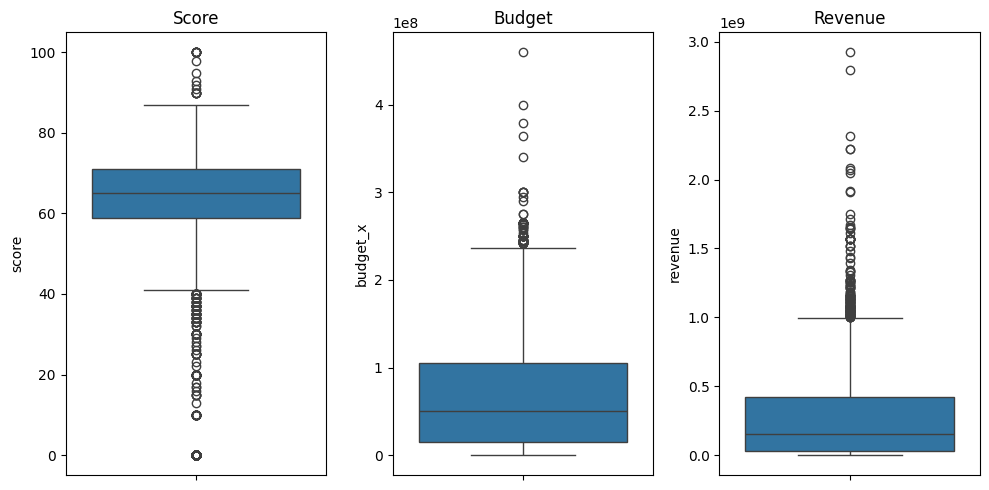

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
sns.boxplot(y=df['score'])
plt.title("Score")

plt.subplot(1,3,2)
sns.boxplot(y=df['budget_x'])
plt.title("Budget")

plt.subplot(1,3,3)
sns.boxplot(y=df['revenue'])
plt.title("Revenue")

plt.tight_layout()
plt.show()

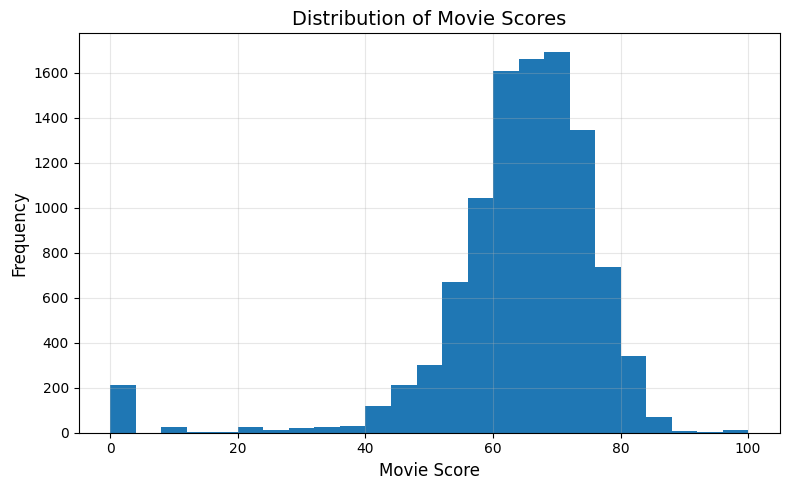

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['score'].dropna(), bins=25)
plt.xlabel("Movie Score", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Movie Scores", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

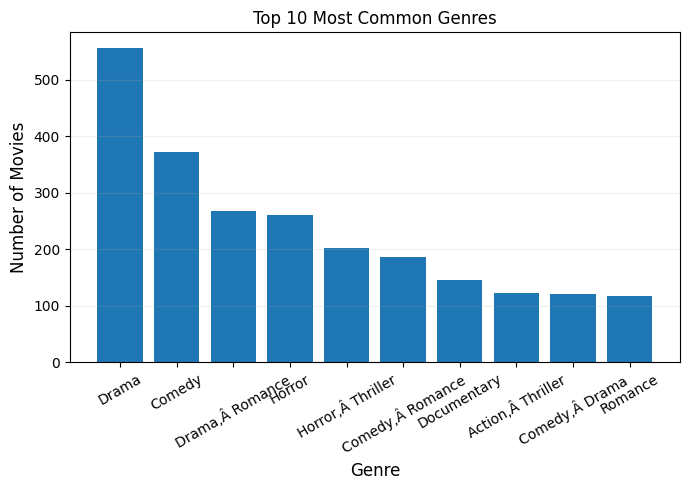

In [14]:
genre_counts = df['genre'].value_counts().head(10)

plt.figure(figsize=(7,5))
plt.bar(genre_counts.index, genre_counts.values)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Number of Movies", fontsize=12)
plt.title("Top 10 Most Common Genres", fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

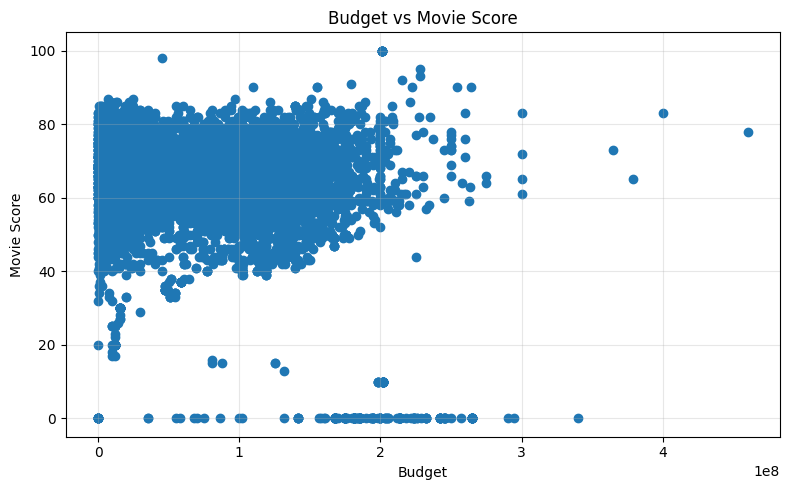

<Figure size 1000x600 with 0 Axes>

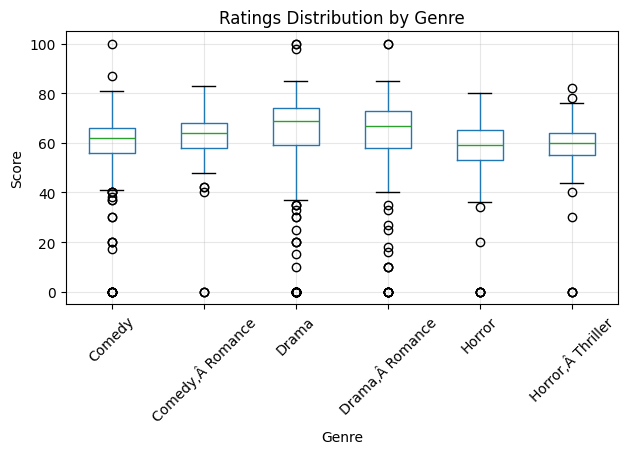

Correlation between Budget and Revenue: 0.674


In [15]:
import matplotlib.pyplot as plt

# 1️⃣ Scatter Plot: Budget vs Score
plt.figure(figsize=(8,5))
plt.scatter(df['budget_x'], df['score'])
plt.xlabel("Budget")
plt.ylabel("Movie Score")
plt.title("Budget vs Movie Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 2️⃣ Boxplot: Score by Genre (Top 6 Genres Only)
top_genres = df['genre'].value_counts().head(6).index
filtered_df = df[df['genre'].isin(top_genres)]

plt.figure(figsize=(10,6))
filtered_df.boxplot(column='score', by='genre')
plt.xlabel("Genre")
plt.ylabel("Score")
plt.title("Ratings Distribution by Genre")
plt.suptitle("")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 3️⃣ Correlation: Budget vs Revenue
correlation = df['budget_x'].corr(df['revenue'])
print("Correlation between Budget and Revenue:", round(correlation, 3))

C:\Users\Kartikay Vyas\AppData\Local\Temp\ipykernel_2228\1694303024.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg.values, y=avg.index, palette="viridis")


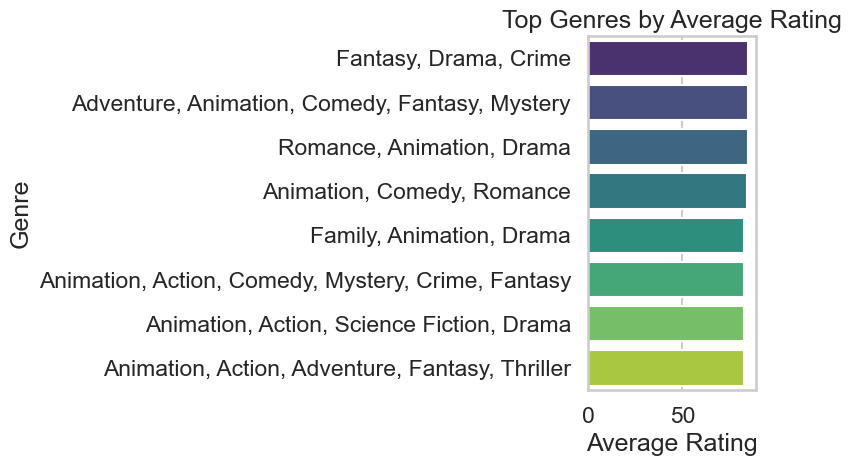

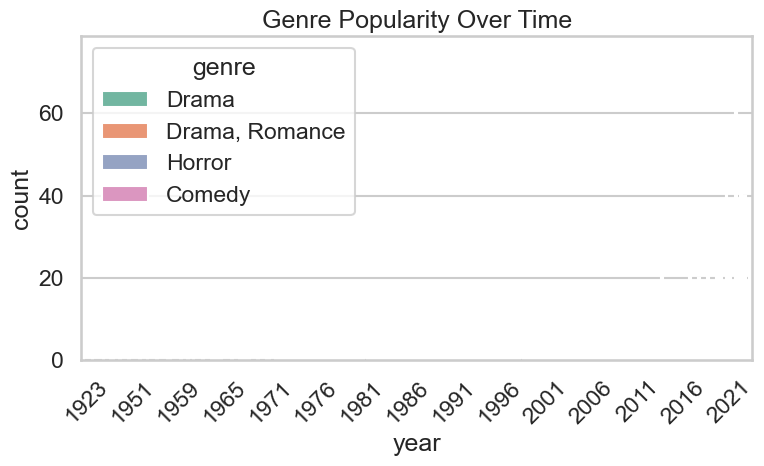

C:\Users\Kartikay Vyas\AppData\Local\Temp\ipykernel_2228\1694303024.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='genre', y='score', palette="pastel")


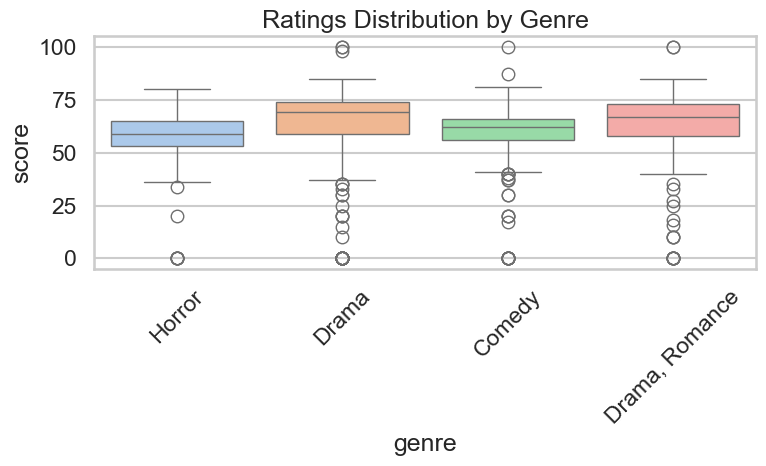

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Fix encoding issue
df['genre'] = df['genre'].str.replace('Â', '')

# -------------------------------
# 1️⃣ Highest Average Rating by Genre
# -------------------------------
avg = df.groupby('genre')['score'].mean().sort_values(ascending=False).head(8)

plt.figure(figsize=(8,5))
sns.barplot(x=avg.values, y=avg.index, palette="viridis")
plt.title("Top Genres by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


# -------------------------------
# 2️⃣ Genre Popularity Over Time
# -------------------------------
top4 = df['genre'].value_counts().head(4).index
data = df[df['genre'].isin(top4)]

plt.figure(figsize=(8,5))
sns.countplot(data=data, x='year', hue='genre', palette='Set2')
plt.xticks(rotation=45)
plt.xticks(ticks=range(0, len(data['year'].unique()), 5))
plt.title("Genre Popularity Over Time")
plt.tight_layout()
plt.show()


# -------------------------------
# 3️⃣ Rating Distribution by Genre
# -------------------------------
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='genre', y='score', palette="pastel")
plt.xticks(rotation=45)
plt.title("Ratings Distribution by Genre")
plt.tight_layout()
plt.show()

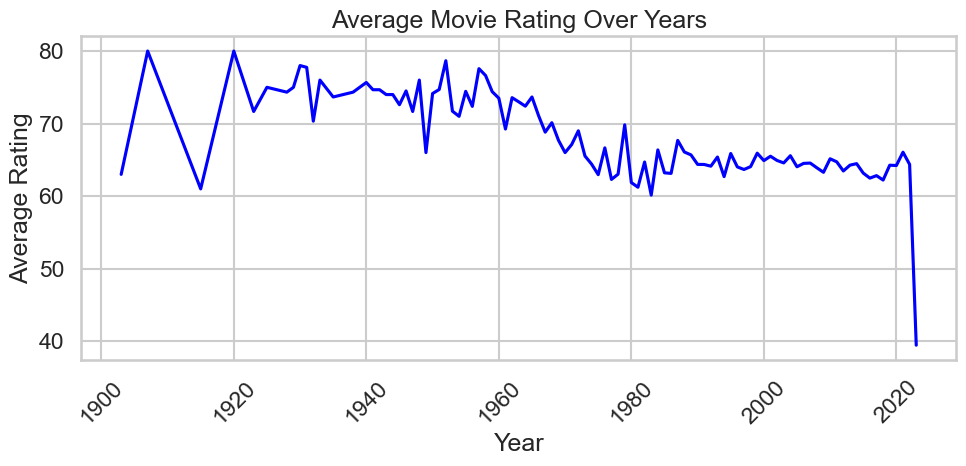

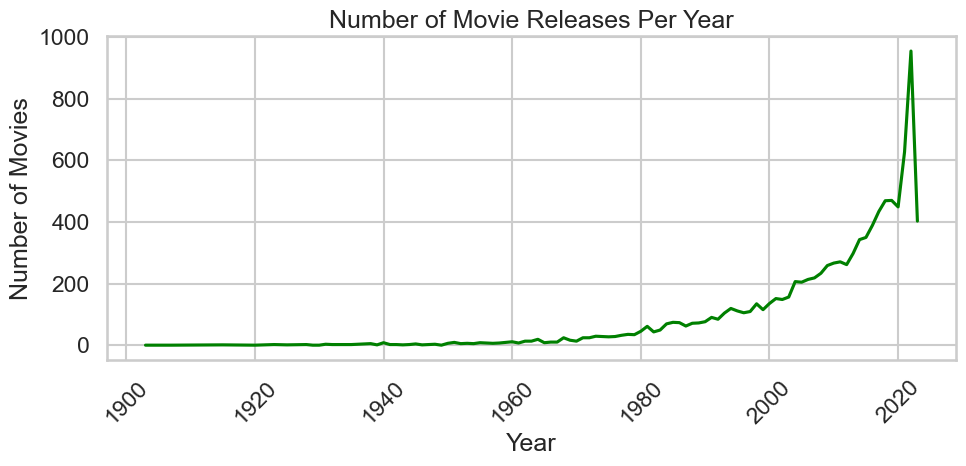

Year with Highest Releases: 2022
Year with Lowest Releases: 1903


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# -------------------------------
# 1️⃣ Average Rating Over Years
# -------------------------------
avg_year = df.groupby('year')['score'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=avg_year.index, y=avg_year.values, color="blue")
plt.title("Average Movie Rating Over Years")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -------------------------------
# 2️⃣ Number of Releases Per Year
# -------------------------------
release_count = df['year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=release_count.index, y=release_count.values, color="green")
plt.title("Number of Movie Releases Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print highest & lowest release years
print("Year with Highest Releases:", release_count.idxmax())
print("Year with Lowest Releases:", release_count.idxmin())

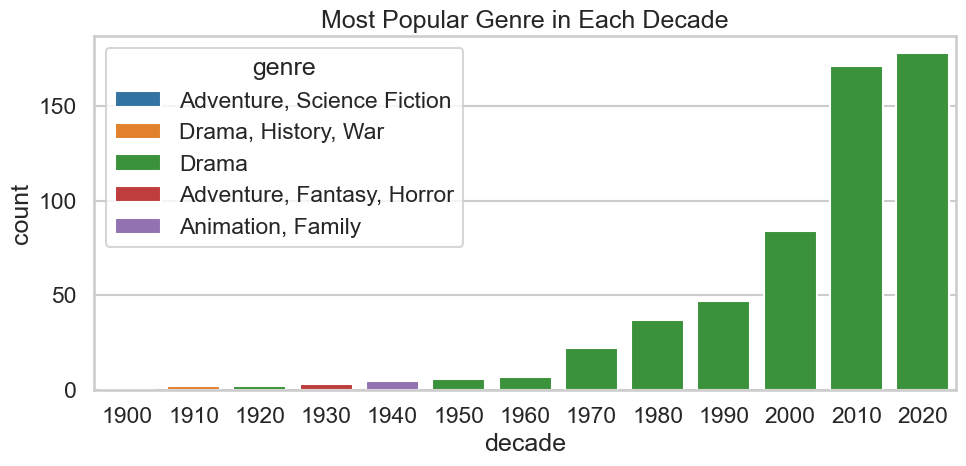

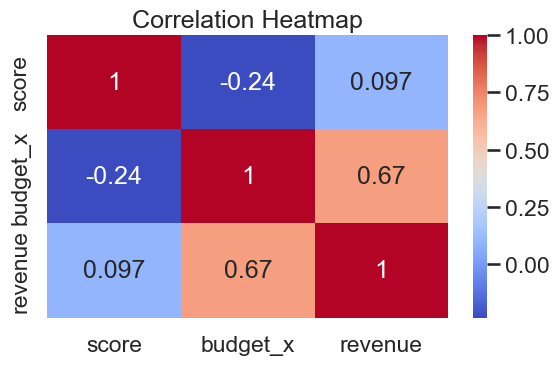

C:\Users\Kartikay Vyas\AppData\Local\Temp\ipykernel_2228\1134285021.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_genre.values, y=avg_genre.index, palette="viridis")


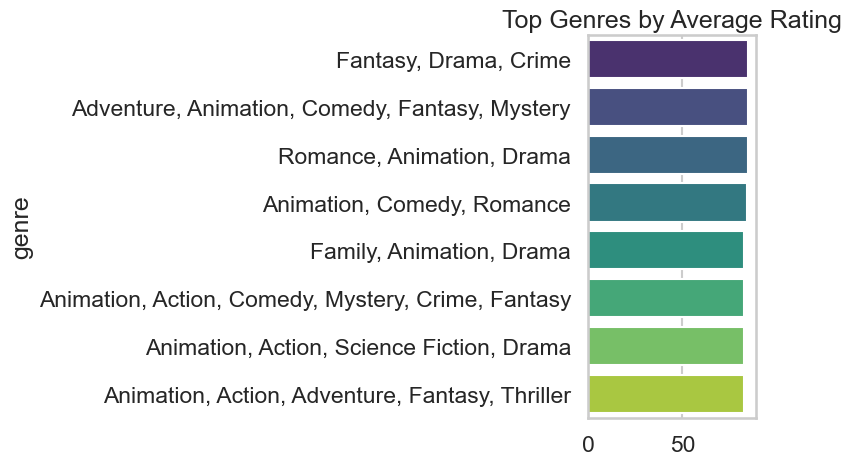

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_style("whitegrid")

# Create Decade Column
df['decade'] = (df['year'] // 10) * 10

# -------------------------------
# 1️⃣ Most Popular Genre per Decade
# -------------------------------
decade_genre = df.groupby(['decade','genre']).size().reset_index(name='count')
top_decade = decade_genre.sort_values(['decade','count'], ascending=[True, False])
top_decade = top_decade.groupby('decade').first().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=top_decade, x='decade', y='count', hue='genre')
plt.title("Most Popular Genre in Each Decade")
plt.tight_layout()
plt.show()


# -------------------------------
# 2️⃣ Heatmap (Numerical Relationships)
# -------------------------------
plt.figure(figsize=(6,4))
sns.heatmap(df[['score','budget_x','revenue']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# -------------------------------
# 3️⃣ Average Rating by Genre
# -------------------------------
plt.figure(figsize=(8,5))
avg_genre = df.groupby('genre')['score'].mean().sort_values(ascending=False).head(8)
sns.barplot(x=avg_genre.values, y=avg_genre.index, palette="viridis")
plt.title("Top Genres by Average Rating")
plt.tight_layout()
plt.show()